# Week 14 - Bivariate Analysis 2, Statistics - Week 2

# 1. Lesson: no lesson this week.

# 2. Weekly graph question

What is your opinion of the graph below?  What are its positive or negative qualities?  How would you fix it?

In [5]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import datetime

In [6]:
size = 5
interval = 30
start = datetime.datetime(2024, 1, 1)
  
lst = [start + datetime.timedelta(days=num_days) * interval for num_days in range(size)]

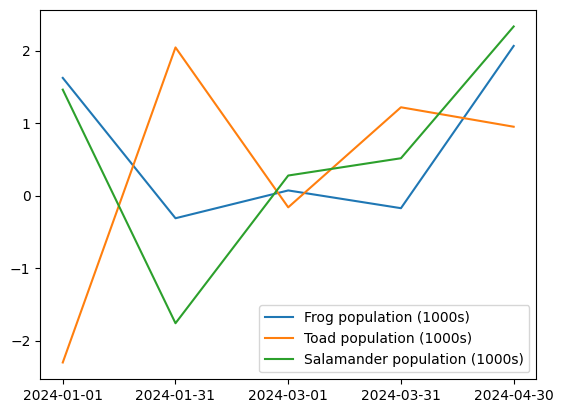

In [7]:
np.random.seed(1)
plt.plot(lst, np.random.normal(size = size) + 0.3 * np.arange(size), label = "Frog population (1000s)")
plt.plot(lst, np.random.normal(size = size) + 0.3 * np.arange(size), label = "Toad population (1000s)")
plt.plot(lst, np.random.normal(size = size) + 0.3 * np.arange(size), label = "Salamander population (1000s)")
plt.xticks(lst)
plt.legend()

Positive Qualities

Clear legend : The three species are labeled with distinct colors making them distinguishable.
Consistent time axis the x-axis uses real dates at roughly monthly intervals, which is appropriate for time series data.
Simple and uncluttered.


Negative Qualities / Problems

1. Missing title
The most glaring issue there's no chart title. A reader has no idea what this graph is about without reading surrounding context. A title like "Amphibian Population Changes in 2024" would be great.
2. Missing y axis label
The y-axis shows values but never explains what they represent. Even though the legend says "(1000s)," the axis itself should be labeled (e.g., "Population Change (thousands)" or "Population (thousands)").
3. Unclear what the y axis is actually measuring
The values go negative (down to −2), which is strange for a population count. This suggests it may be representing change or deviation, not raw population — but that's never stated. This is deeply confusing.
4. Volatile, unexplained trends
The lines swing dramatically with no annotations or context. Without knowing what caused the spikes and drops, the graph raises more questions than it answers.
5. X-axis label is missing

Suggested Fixes

Add a descriptive title
Label both axes
Clarify whether the y axis shows absolute population or change in population
Consider adding annotations for notable events (eg, a breeding season or habitat disruption)
If the data represents change, consider a bar chart instead, which more intuitively shows positive/negative deltas

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Run t-tests and Mann Whitney U tests to compare different sets of numbers.
  * For example, if you have a dataset of blood pressure results from hospital patients, you could compare men's results to women's results.
* Run ANOVA tests to compare more than two sets of numbers.
  * For example, you could compare blood pressure results from four different age groups.
* Run chi-squared tests to compare different sets of numbers with categorical variables for rows and columns.
  * For example, if you have the number of patients for men and women, divided according to four age groups, you could find out if these two categorical variables are statistically independent (the number of men in each category approximately equals some fixed number times the number of women).

T-test p-value: 0.0035605188517103
Mann-Whitney p-value: 8.578472310840218e-06
T-test: Significant difference in transaction amounts (Fraud vs Non-Fraud).


/var/folders/2y/zwy095dx4pv0v_d2ywk3w40r0000gn/T/ipykernel_3236/625099999.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([fraud, non_fraud], labels=["Fraud", "Non-Fraud"])


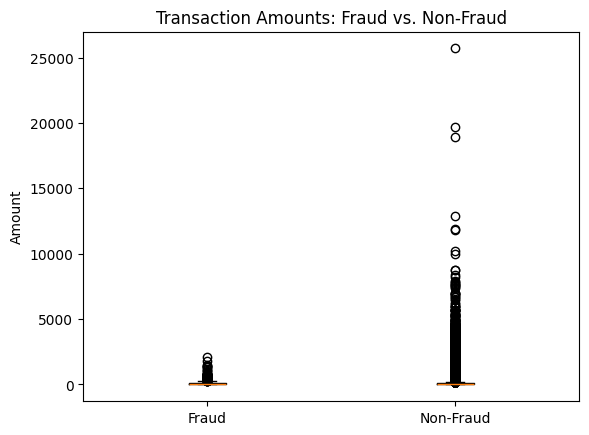


ANOVA p-value: 3.07994732345978e-137
ANOVA: At least one time segment differs in average amount.


/var/folders/2y/zwy095dx4pv0v_d2ywk3w40r0000gn/T/ipykernel_3236/625099999.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=[f"Segment {i}" for i in range(len(groups))])


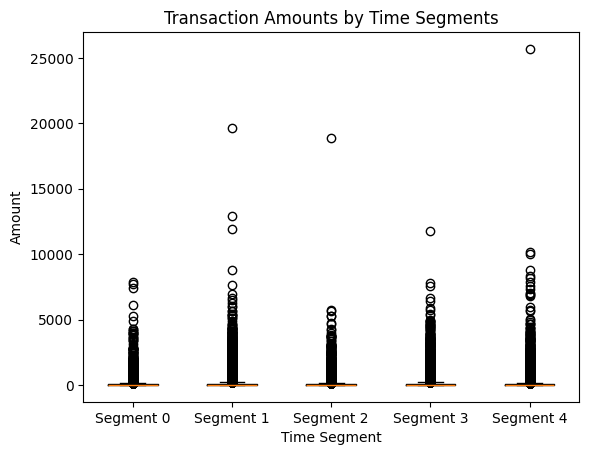


Chi-square p-value: 2.6857868149759218e-17
Chi-square: Time segments and fraud occurrence are related.


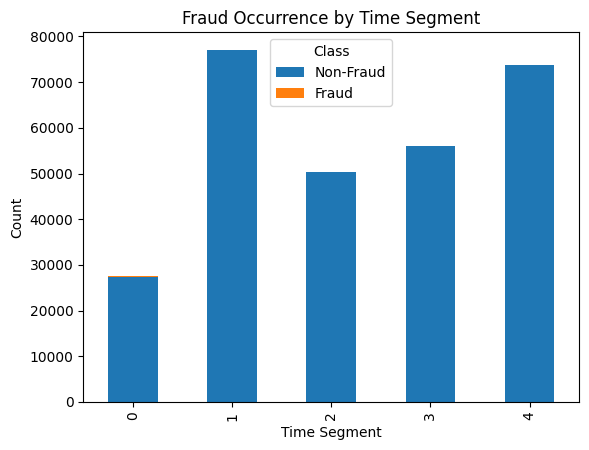

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Load the credit card dataset
df = pd.read_csv("creditcard_final.csv")

# T-test and Mann-Whitney U: Fraud vs Non-Fraud transaction amounts
fraud = df[df['Class'] == 1]['Amount']
non_fraud = df[df['Class'] == 0]['Amount']

t_stat, t_p = stats.ttest_ind(fraud, non_fraud, equal_var=False)
u_stat, u_p = stats.mannwhitneyu(fraud, non_fraud)

print("T-test p-value:", t_p)
print("Mann-Whitney p-value:", u_p)

if t_p < 0.05:
    print("T-test: Significant difference in transaction amounts (Fraud vs Non-Fraud).")
else:
    print("T-test: No significant difference.")

plt.boxplot([fraud, non_fraud], labels=["Fraud", "Non-Fraud"])
plt.title("Transaction Amounts: Fraud vs. Non-Fraud")
plt.ylabel("Amount")
plt.show()

# ANOVA: Compare average transaction amount by time segments
df['time_segment'] = pd.cut(df['Time'], bins=5, labels=False)
groups = [df[df['time_segment'] == segment]['Amount'] for segment in df['time_segment'].unique()]

anova_result = stats.f_oneway(*groups)

print("\nANOVA p-value:", anova_result.pvalue)
if anova_result.pvalue < 0.05:
    print("ANOVA: At least one time segment differs in average amount.")
else:
    print("ANOVA: No significant difference between segments.")

plt.boxplot(groups, labels=[f"Segment {i}" for i in range(len(groups))])
plt.title("Transaction Amounts by Time Segments")
plt.ylabel("Amount")
plt.xlabel("Time Segment")
plt.show()

# Chi-square: Check the relationship between time segment and fraud
contingency = pd.crosstab(df['time_segment'], df['Class'])

chi2, p, _, _ = stats.chi2_contingency(contingency)

print("\nChi-square p-value:", p)
if p < 0.05:
    print("Chi-square: Time segments and fraud occurrence are related.")
else:
    print("Chi-square: No significant relationship.")

contingency.plot(kind='bar', stacked=True)
plt.title("Fraud Occurrence by Time Segment")
plt.xlabel("Time Segment")
plt.ylabel("Count")
plt.legend(title="Class", labels=["Non-Fraud", "Fraud"])
plt.show()

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 228-255 (chapter nine, Case Study 4 through the end of chapter 10) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

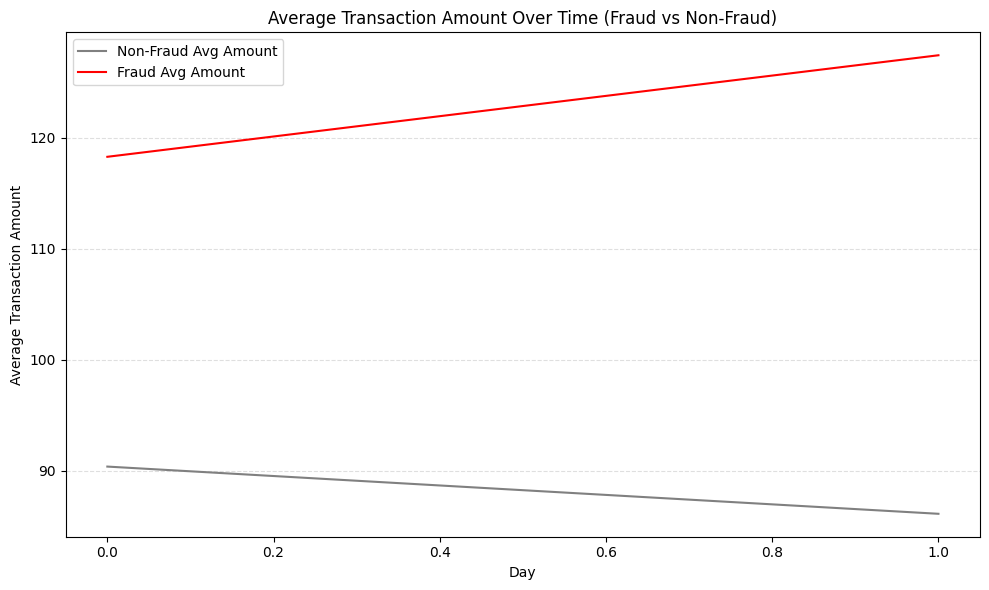

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("creditcard_final.csv")

# Create Day column from Time
df['Day'] = (df['Time'] // (60 * 60 * 24)).astype(int)

# Group data: average Amount by Day and Fraud (Class)
grouped = df.groupby(['Day', 'Class'])['Amount'].mean().unstack()

# Plot
plt.figure(figsize=(10,6))

# Non-Fraud (Class = 0)
plt.plot(grouped.index, grouped[0], label='Non-Fraud Avg Amount', color='gray')

# Fraud (Class = 1)
plt.plot(grouped.index, grouped[1], label='Fraud Avg Amount', color='red')

# Labels and title
plt.xlabel("Day")
plt.ylabel("Average Transaction Amount")
plt.title("Average Transaction Amount Over Time (Fraud vs Non-Fraud)")

# Clean style (Storytelling with Data style)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


# This chart shows how transaction amounts change over time.
# Fraud transactions tend to differ from non-fraud transactions, which helps highlight unusual patterns in the data.